# Exploratory Data Analysis of Thyroid Dataset

### About Dataset
This data set contains 13 clinicopathologic features aiming to predict recurrence of well differentiated thyroid cancer. The data set was collected in duration of 15 years and each patient was followed for at least 10 years.

**List of attributes, and their description summaries:**

- **Age:** The age of the patient at the time of diagnosis or treatment.
- **Gender:** The gender of the patient (male or female).
- **Smoking:** Whether the patient is a smoker or not.
- **Hx Smoking:** Smoking history of the patient (e.g., whether they have ever smoked).
- **Hx Radiotherapy:** History of radiotherapy treatment for any condition.
- **Thyroid Function:** The status of thyroid function, possibly indicating if there are any abnormalities.
- **Physical Examination:** Findings from a physical examination of the patient, which may include palpation of the thyroid gland and surrounding structures.
- **Adenopathy:** Presence or absence of enlarged lymph nodes (adenopathy) in the neck region.
- **Pathology:** Specific types of thyroid cancer as determined by pathology examination of biopsy samples.
- **Focality:** Whether the cancer is unifocal (limited to one location) or multifocal (present in multiple locations).
- **Risk:** The risk category of the cancer based on various factors, such as tumor size, extent of spread, and histological type.
- **T:** Tumor classification based on its size and extent of invasion into nearby structures.
- **N:** Nodal classification indicating the involvement of lymph nodes.
- **M:** Metastasis classification indicating the presence or absence of distant metastases.
- **Stage:** The overall stage of the cancer, typically determined by combining T, N, and M classifications.
- **Response:** Response to treatment, indicating whether the cancer responded positively, negatively, or remained stable after treatment.
- **Recurred:** Indicates whether the cancer has recurred after initial treatment.

### 1) Import Libraries

In [1]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data"


#----- Tools, visualizers -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import *


### 2) Load and Inspect data

In [2]:
#---------------
# Load dataset
#---------------
data = pd.read_csv(DATA_DIR / "Thyroid_Diff.csv")
data

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [3]:
#-----------------
# Inspect & Info
#-----------------

# Get info and statistics
print(data.info())
print(data.describe().T)
print(20*"--")
# Check shape of the dataset
print(f"Shape of the dataset: {data.shape}")
# Count missing values
print(f"Counts of missing values:\n{data.isna().sum()}")
# Count duplicated values
print(f"Counts of duplicated values: {data.duplicated().sum()}")
# Check uniqueness of values
# Count unique values in each col
print(data.nunique())
# Get columns & their unique values
unique_values = {col: data[col].unique().tolist()
                  for col, value in zip(data.columns.tolist(), data.nunique()) if value <= 10}
unique_values

<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Recurred           

{'Gender': ['F', 'M'],
 'Smoking': ['No', 'Yes'],
 'Hx Smoking': ['No', 'Yes'],
 'Hx Radiothreapy': ['No', 'Yes'],
 'Thyroid Function': ['Euthyroid',
  'Clinical Hyperthyroidism',
  'Clinical Hypothyroidism',
  'Subclinical Hyperthyroidism',
  'Subclinical Hypothyroidism'],
 'Physical Examination': ['Single nodular goiter-left',
  'Multinodular goiter',
  'Single nodular goiter-right',
  'Normal',
  'Diffuse goiter'],
 'Adenopathy': ['No', 'Right', 'Extensive', 'Left', 'Bilateral', 'Posterior'],
 'Pathology': ['Micropapillary', 'Papillary', 'Follicular', 'Hurthel cell'],
 'Focality': ['Uni-Focal', 'Multi-Focal'],
 'Risk': ['Low', 'Intermediate', 'High'],
 'T': ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],
 'N': ['N0', 'N1b', 'N1a'],
 'M': ['M0', 'M1'],
 'Stage': ['I', 'II', 'IVB', 'III', 'IVA'],
 'Response': ['Indeterminate',
  'Excellent',
  'Structural Incomplete',
  'Biochemical Incomplete'],
 'Recurred': ['No', 'Yes']}

#### - Check duplicates

In [18]:
dup_data = data[data.duplicated() == True]
dup_data

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
32,36,F,No,No,No,Euthy,SingleR,No,Micro,Uni,Low,T1a,N0,M0,I,Exc,No
38,40,F,No,No,No,Euthy,SingleR,No,Micro,Uni,Low,T1a,N0,M0,I,Exc,No
40,51,F,No,No,No,Euthy,SingleR,No,Micro,Uni,Low,T1a,N0,M0,I,Exc,No
66,35,F,No,No,No,Euthy,SingleR,No,Papp,Uni,Low,T1b,N0,M0,I,Exc,No
69,51,F,No,No,No,Euthy,SingleL,No,Papp,Uni,Low,T1b,N0,M0,I,Exc,No
77,29,F,No,No,No,Euthy,SingleR,No,Papp,Uni,Low,T1b,N0,M0,I,Exc,No
120,37,F,No,No,No,Euthy,SingleR,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No
121,26,F,No,No,No,Euthy,Multi,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No
123,28,F,No,No,No,Euthy,SingleR,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No
132,32,F,No,No,No,Euthy,SingleR,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No


In [ ]:
# Ages: 51, 26, 32
dup_data[(dup_data['Age'] == 51)  | (dup_data['Age'] == 26) | (dup_data['Age'] == 32)].sort_values(by='Age')

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
121,26,F,No,No,No,Euthy,Multi,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No
138,26,F,No,No,No,Euthy,Multi,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No
183,26,F,No,No,No,Euthy,Multi,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No
132,32,F,No,No,No,Euthy,SingleR,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No
137,32,F,No,No,No,Euthy,SingleR,No,Papp,Uni,Low,T2,N0,M0,I,Exc,No
69,51,F,No,No,No,Euthy,SingleL,No,Papp,Uni,Low,T1b,N0,M0,I,Exc,No
40,51,F,No,No,No,Euthy,SingleR,No,Micro,Uni,Low,T1a,N0,M0,I,Exc,No


### 3) Check Distributions

#### - Categorical features

In [4]:
#-------------------------------------
# Count values of categorical features 
#-------------------------------------

# Get object categorical features 
cat_cols = data.select_dtypes(include=['object', 'string'])
# Print each column's value counts
for f in cat_cols:
    print(data[f].value_counts(), end="\n\n")
    print(data[f].value_counts(normalize=True))
    print(20*"---")

Gender
F    312
M     71
Name: count, dtype: int64

Gender
F    0.814621
M    0.185379
Name: proportion, dtype: float64
------------------------------------------------------------
Smoking
No     334
Yes     49
Name: count, dtype: int64

Smoking
No     0.872063
Yes    0.127937
Name: proportion, dtype: float64
------------------------------------------------------------
Hx Smoking
No     355
Yes     28
Name: count, dtype: int64

Hx Smoking
No     0.926893
Yes    0.073107
Name: proportion, dtype: float64
------------------------------------------------------------
Hx Radiothreapy
No     376
Yes      7
Name: count, dtype: int64

Hx Radiothreapy
No     0.981723
Yes    0.018277
Name: proportion, dtype: float64
------------------------------------------------------------
Thyroid Function
Euthyroid                      332
Clinical Hyperthyroidism        20
Subclinical Hypothyroidism      14
Clinical Hypothyroidism         12
Subclinical Hyperthyroidism      5
Name: count, dtype: int64

Thyro

### - Shorten value names

In [5]:
df = data
for col, mapping in short_names.items():
    df[col] = df[col].replace(mapping)

df

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthy,SingleL,No,Micro,Uni,Low,T1a,N0,M0,I,Indet,No
1,34,F,No,Yes,No,Euthy,Multi,No,Micro,Uni,Low,T1a,N0,M0,I,Exc,No
2,30,F,No,No,No,Euthy,SingleR,No,Micro,Uni,Low,T1a,N0,M0,I,Exc,No
3,62,F,No,No,No,Euthy,SingleR,No,Micro,Uni,Low,T1a,N0,M0,I,Exc,No
4,62,F,No,No,No,Euthy,Multi,No,Micro,Multi,Low,T1a,N0,M0,I,Exc,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthy,SingleR,R,Papp,Uni,High,T4b,N1b,M1,IVB,Bio,Yes
379,81,M,Yes,No,Yes,Euthy,Multi,Ext,Papp,Multi,High,T4b,N1b,M1,IVB,Struct,Yes
380,72,M,Yes,Yes,No,Euthy,Multi,Bil,Papp,Multi,High,T4b,N1b,M1,IVB,Struct,Yes
381,61,M,Yes,Yes,Yes,Hyper,Multi,Ext,Hurth,Multi,High,T4b,N1b,M0,IVA,Struct,Yes


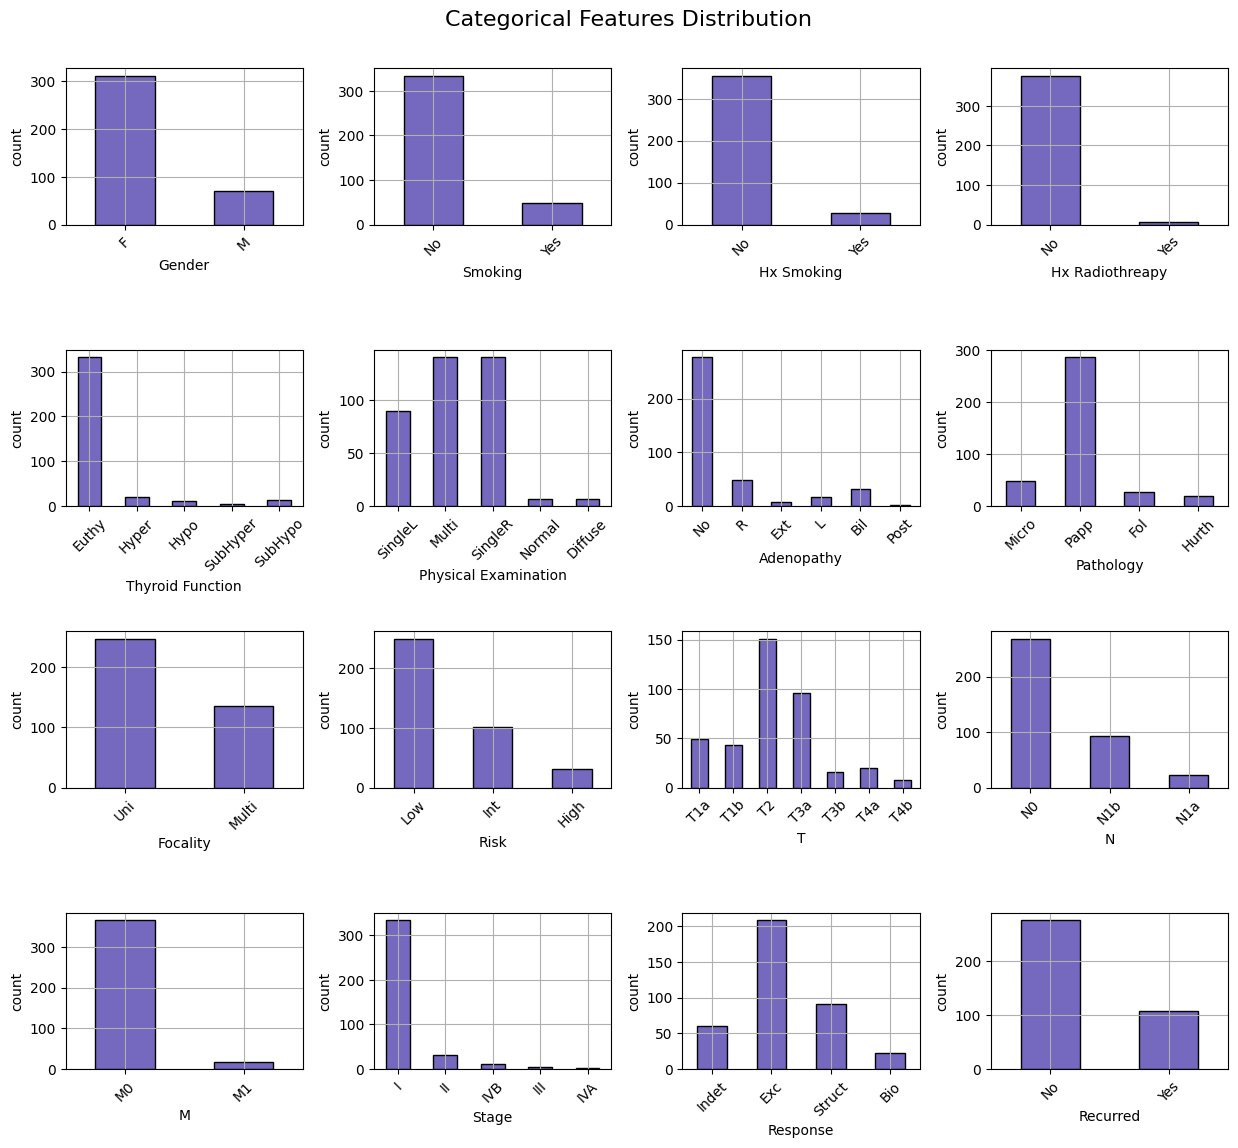

In [24]:
#-----------------------------------------
# Categorical features distribution using bars
#-----------------------------------------

# Get categorical cols with shortened value names
df_cat_cols = data.select_dtypes(include=['object', 'string'])

# Create figure and its size/shape
fig, axes = plt.subplots(4, 4, figsize=(15, 13))

# Flatten axes array for easy looping
axes = axes.flatten()

# Loop through the dataframe and get (index, column)
for i, col in enumerate(df_cat_cols):
    # Adjust the plot
    sns.countplot(x=col, data=df_cat_cols, ax=axes[i], width=0.5,
                   color='slateblue', edgecolor='black')
    axes[i].tick_params(axis='x', labelrotation=45)
    # Add grids
    axes[i].grid()

# If there are empty subplots, remove them
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.suptitle("Categorical Features Distribution", fontsize=16, y=0.925)
plt.show()

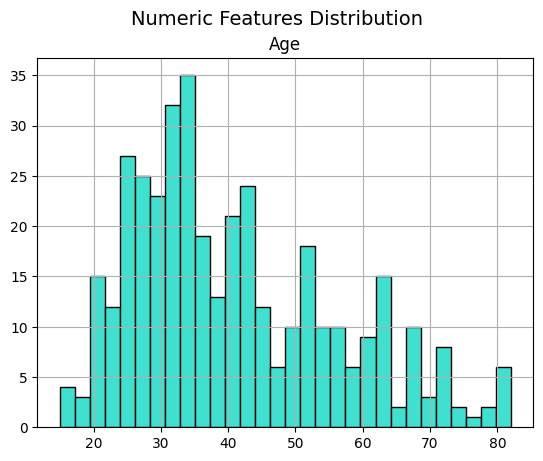

In [6]:
#------------------------------------------------------------
# Continuous numerical features distribution using Histogram
#------------------------------------------------------------

# Get continuous numerical features
num_cols = data.select_dtypes(include='number')

# Visualize features distribution -> Age is the only feature
num_cols.hist(
    color='turquoise',
    edgecolor='black',
    bins=30
)

plt.suptitle("Numeric Features Distribution", fontsize=14)
plt.show()

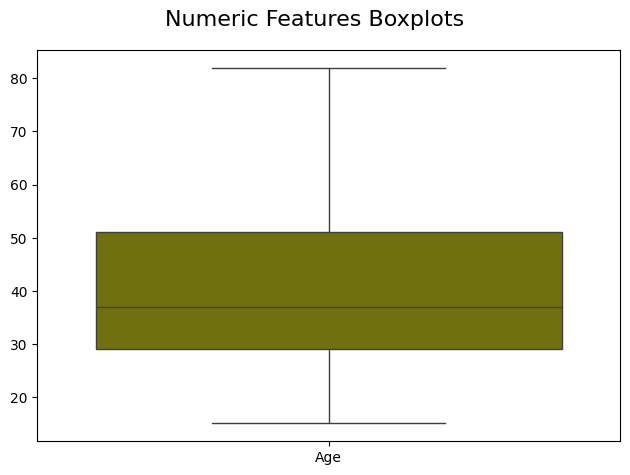

In [35]:
#----------------------------------------------
# Visualize numeric features by using Boxplot
#----------------------------------------------

def boxplot(train, color="olive", title="Numeric Features Boxplots"):

    sns.boxplot(data=train, color=color)
    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel("")  # Remove x-labels for clean look

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

boxplot(num_cols)


### 6) Check skewness and outliers of numerical features

In [36]:
skewness_detector(num_cols)

,Feature,Skewness,Skewness_Exceeding_Threshold
0,Age,0.719732,False


In [37]:
outlier_detector(num_cols)

,Feature,N_outliers,Outlier_pct
0,Age,0,0.0


### 4) Check correlation of features

In [7]:
# Get columns name as lists
numeric_features = num_cols.columns.tolist()
categorical_features = cat_cols.columns.tolist()

analyzer = CorrelationAnalyzer(
    data=data,
    target_type="None",        # This is an UNSUPERVISED project
    num_cols=numeric_features,
    cat_cols=categorical_features,
    target_col=None
)


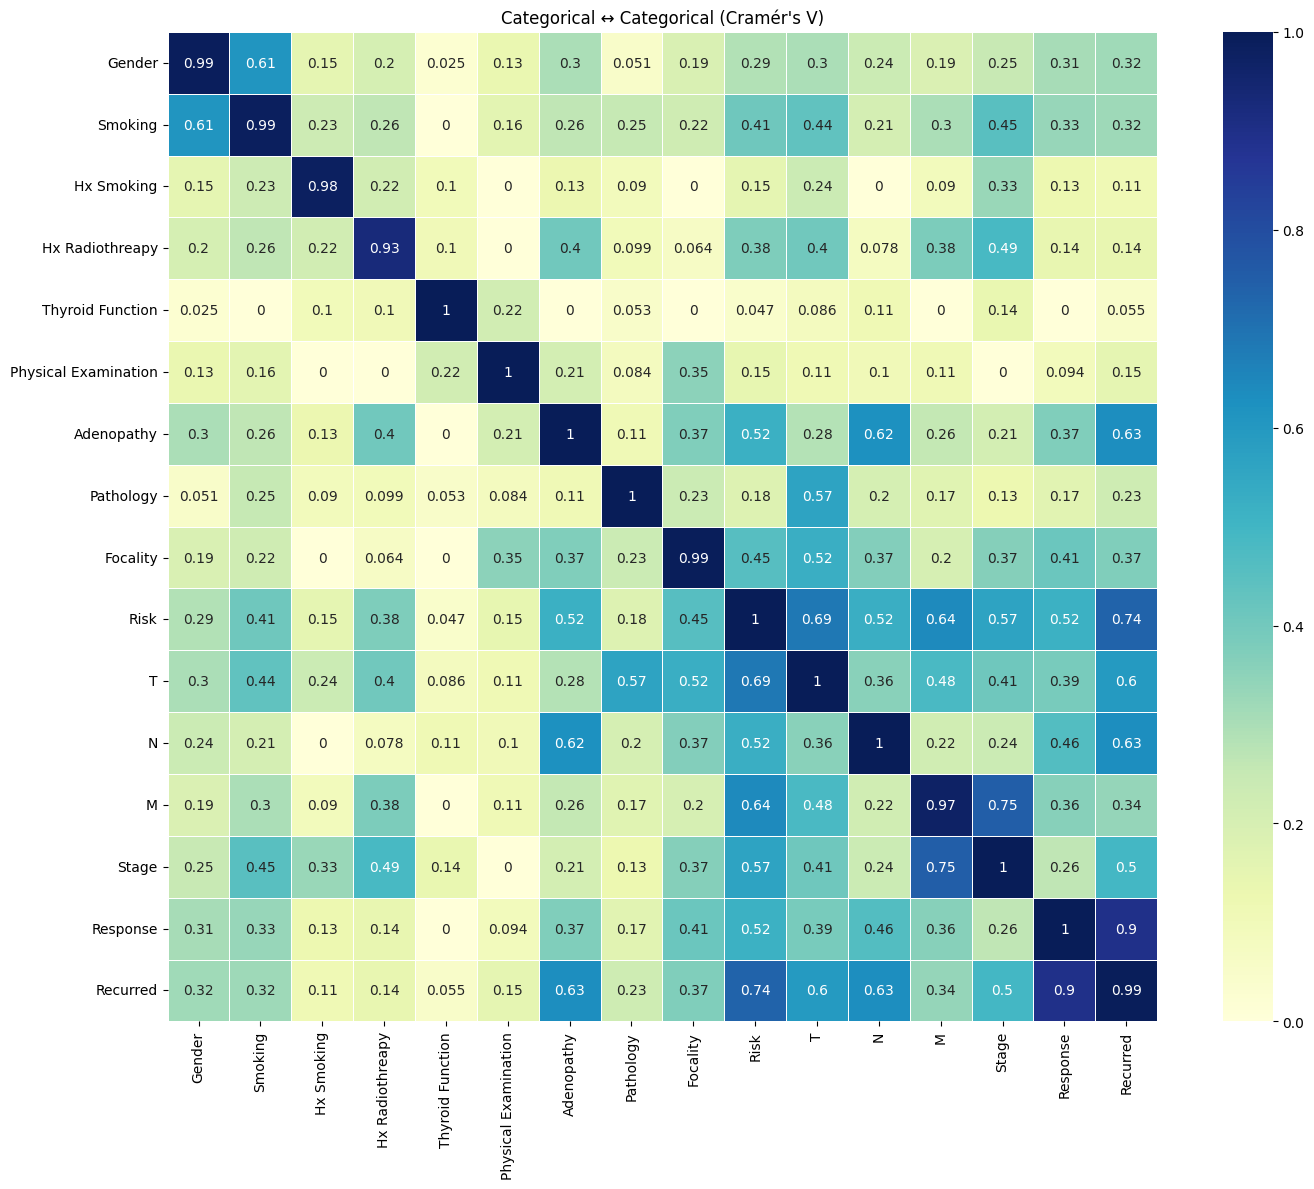

In [8]:
analyzer.plot_cat_cat(figsize=(15, 12))

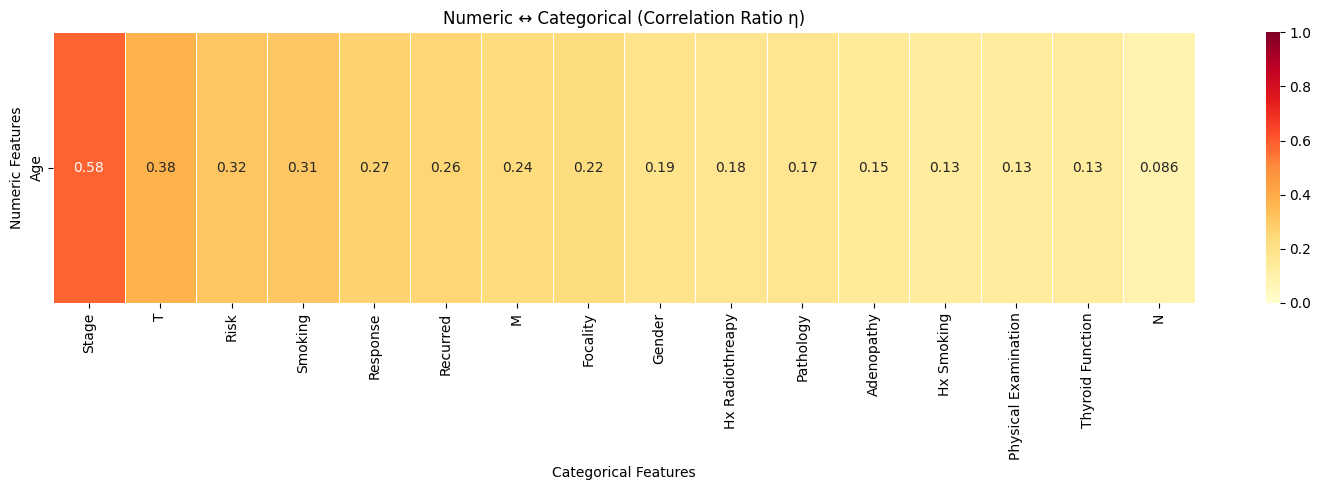

In [9]:
analyzer.plot_num_cat(figsize=(15, 5))